In [3]:
import numpy as np
import pandas as pd
import scipy.io as sio
import os, glob, warnings, time
from scipy import stats
from scipy.signal import welch
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
os.makedirs('/kaggle/working/figures', exist_ok=True)
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

GPU: []


2026-04-27 23:29:15.701431: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
BASE = '/kaggle/input/datasets/emperorpein/mfpt-fault-datasets/MFPT Fault Data Sets'
# BASE path to where the MFPT dataset is stored

# Hardcoded list every .mat file with its severity label
# Severity: 0 = healthy bearing (baseline), 1 = outer race fault, 2 = inner race fault
file_list = [
    # 3 Baseline (healthy)
    (f"{BASE}/1 - Three Baseline Conditions/baseline_1.mat", 0),
    (f"{BASE}/1 - Three Baseline Conditions/baseline_2.mat", 0),
    (f"{BASE}/1 - Three Baseline Conditions/baseline_3.mat", 0),
    # 10 Outer race faults
    (f"{BASE}/2 - Three Outer Race Fault Conditions/OuterRaceFault_1.mat", 1),
    (f"{BASE}/2 - Three Outer Race Fault Conditions/OuterRaceFault_2.mat", 1),
    (f"{BASE}/2 - Three Outer Race Fault Conditions/OuterRaceFault_3.mat", 1),
    (f"{BASE}/3 - Seven More Outer Race Fault Conditions/OuterRaceFault_vload_1.mat", 1),
    (f"{BASE}/3 - Seven More Outer Race Fault Conditions/OuterRaceFault_vload_2.mat", 1),
    (f"{BASE}/3 - Seven More Outer Race Fault Conditions/OuterRaceFault_vload_3.mat", 1),
    (f"{BASE}/3 - Seven More Outer Race Fault Conditions/OuterRaceFault_vload_4.mat", 1),
    (f"{BASE}/3 - Seven More Outer Race Fault Conditions/OuterRaceFault_vload_5.mat", 1),
    (f"{BASE}/3 - Seven More Outer Race Fault Conditions/OuterRaceFault_vload_6.mat", 1),
    (f"{BASE}/3 - Seven More Outer Race Fault Conditions/OuterRaceFault_vload_7.mat", 1),
    # 7 Inner race faults
    (f"{BASE}/4 - Seven Inner Race Fault Conditions/InnerRaceFault_vload_1.mat", 2),
    (f"{BASE}/4 - Seven Inner Race Fault Conditions/InnerRaceFault_vload_2.mat", 2),
    (f"{BASE}/4 - Seven Inner Race Fault Conditions/InnerRaceFault_vload_3.mat", 2),
    (f"{BASE}/4 - Seven Inner Race Fault Conditions/InnerRaceFault_vload_4.mat", 2),
    (f"{BASE}/4 - Seven Inner Race Fault Conditions/InnerRaceFault_vload_5.mat", 2),
    (f"{BASE}/4 - Seven Inner Race Fault Conditions/InnerRaceFault_vload_6.mat", 2),
    (f"{BASE}/4 - Seven Inner Race Fault Conditions/InnerRaceFault_vload_7.mat", 2),
    # Analyses
    (f"{BASE}/5 - Analyses/InnerRaceFault_vload_7.mat", 2),
]

recordings = []  #list to sore loaded recordings
for filepath, severity in file_list:   #Looping file path and severity label
    if not os.path.exists(filepath):
        print(f"  NOT FOUND: {filepath}")  
        continue
    try:
        mat = sio.loadmat(filepath)   #Loading the .mat file
        b = mat['bearing']            #Extracting the 'bearing' structure from file
        sig = b['gs'][0][0].flatten().astype(np.float64)   #Extracting the vibration signal array ('gs' = g force signal)
        sr = int(b['sr'][0][0].flatten()[0])   #Extracting the sample rate
        load = float(b['load'][0][0].flatten()[0])   # Extracting the load value (for severity ordering)
        recordings.append({  #storing
            'signal': sig, 
            'severity': severity,  #0, 1, 2
            'load': load, 
            'name': os.path.basename(filepath),
            'sr': sr
        })
        print(f"  Loaded: {os.path.basename(filepath):40s} severity={severity}  load={load:.0f}  sr={sr}  samples={len(sig)}")
    except Exception as e:
        print(f"  ERROR: {os.path.basename(filepath)}: {e}")
# Print summary of loading
print(f"\nTotal recordings loaded: {len(recordings)}")   # 21
print(f"  Healthy (0): {sum(1 for r in recordings if r['severity']==0)}")  # 3
print(f"  Outer race (1): {sum(1 for r in recordings if r['severity']==1)}") # 10
print(f"  Inner race (2): {sum(1 for r in recordings if r['severity']==2)}") # 8

  Loaded: baseline_1.mat                           severity=0  load=270  sr=97656  samples=585936
  Loaded: baseline_2.mat                           severity=0  load=270  sr=97656  samples=585936
  Loaded: baseline_3.mat                           severity=0  load=270  sr=97656  samples=585936
  Loaded: OuterRaceFault_1.mat                     severity=1  load=270  sr=97656  samples=585936
  Loaded: OuterRaceFault_2.mat                     severity=1  load=270  sr=97656  samples=585936
  Loaded: OuterRaceFault_3.mat                     severity=1  load=270  sr=97656  samples=585936
  Loaded: OuterRaceFault_vload_1.mat               severity=1  load=25  sr=48828  samples=146484
  Loaded: OuterRaceFault_vload_2.mat               severity=1  load=50  sr=48828  samples=146484
  Loaded: OuterRaceFault_vload_3.mat               severity=1  load=100  sr=48828  samples=146484
  Loaded: OuterRaceFault_vload_4.mat               severity=1  load=150  sr=48828  samples=146484
  Loaded: OuterRaceFau

  baseline_1.mat                           → 1143 windows
  baseline_2.mat                           → 1143 windows
  baseline_3.mat                           → 1143 windows
  OuterRaceFault_vload_1.mat               → 285 windows
  OuterRaceFault_vload_2.mat               → 285 windows
  OuterRaceFault_vload_3.mat               → 285 windows
  OuterRaceFault_vload_4.mat               → 285 windows
  OuterRaceFault_vload_5.mat               → 285 windows
  OuterRaceFault_vload_6.mat               → 285 windows
  OuterRaceFault_1.mat                     → 1143 windows
  OuterRaceFault_2.mat                     → 1143 windows
  OuterRaceFault_3.mat                     → 1143 windows
  OuterRaceFault_vload_7.mat               → 285 windows
  InnerRaceFault_vload_1.mat               → 285 windows
  InnerRaceFault_vload_2.mat               → 285 windows
  InnerRaceFault_vload_3.mat               → 285 windows
  InnerRaceFault_vload_4.mat               → 285 windows
  InnerRaceFault_vload_5.

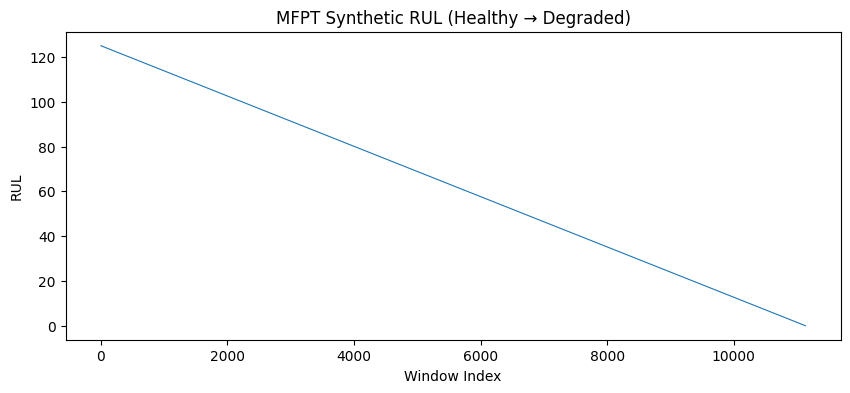

In [5]:
# MFPT has no run-to-failure data. RUL is constructed by ordering
# recordings from healthy to most degraded and assigning linear RUL.

RUL_CAP = 125      # Maximum RUL value
WINDOW_SIZE = 1024 # Each window contains 1024 vibration samples
STEP = 512         # Step size between windows (50%) overlap

# Sorting recoridngs healthy to most degraded
# Primary sort: severity groups
# Secondary sort: Load within groups
recordings.sort(key=lambda x: (x['severity'], x['load']))

all_windows = []    # Holding all windows
window_labels = []  # tracking which recording each window came from

for idx, rec in enumerate(recordings):    # Loops recordings in degradation order
    sig = rec['signal']
    n_wins = (len(sig) - WINDOW_SIZE) // STEP + 1   #accounting for step size
    for i in range(n_wins):   # Extracting each windpw
        start = i * STEP
        all_windows.append(sig[start:start + WINDOW_SIZE])
    window_labels.extend([idx] * n_wins)
    print(f"  {rec['name']:40s} → {n_wins} windows") # all windows sliced and ordered

all_windows = np.array(all_windows, dtype=np.float32)  # converts list to numpy array 
N_WINDOWS = len(all_windows)   # Total number of windows

# Assigning RUL linearly across array
rul_labels = np.linspace(RUL_CAP, 0, N_WINDOWS).astype(np.float32)

print(f"\nTotal windows: {N_WINDOWS}")
print(f"RUL range: {rul_labels.max():.1f} → {rul_labels.min():.1f}")

# Plotting RUL distribution for visualisation
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rul_labels, lw=0.8)
ax.set_xlabel('Window Index'); ax.set_ylabel('RUL')
ax.set_title('MFPT Synthetic RUL (Healthy → Degraded)')
plt.savefig('/kaggle/working/figures/mfpt_rul_distribution.png', bbox_inches='tight')
plt.show()

In [17]:
def extract_features(windows):
    feats = []        # holds the 12 features for each window
    for w in windows: # looping every window
        # Time-doman
        rms = np.sqrt(np.mean(w ** 2))    # Root Mean Square
        peak = np.max(np.abs(w))          # Peak apmlitude
        kurt = stats.kurtosis(w)          # Kurtosis
        skew = stats.skew(w)              # Skewness
        crest = peak / (rms + 1e-8)       # Crest Factor
        std = np.std(w)                   # Standard deviation
        mean_abs = np.mean(np.abs(w))     # Mean absolute value
        shape = rms / (mean_abs + 1e-8)   # Shape factor
        # Frequency domain
        freqs, psd = welch(w, nperseg=256)      # Welch's method
        psd_norm = psd / (psd.sum() + 1e-8)     # Normalise PSD
        spec_centroid = np.sum(freqs * psd_norm) # Spectral centroid
        spec_rms = np.sqrt(np.sum(freqs ** 2 * psd_norm)) # Spectral RMS frequency
        spec_kurt = stats.kurtosis(psd)   # Spectral kurtosis
        peak_freq = freqs[np.argmax(psd)]  # Peak frequency
        feats.append([rms, peak, kurt, skew, crest, std, mean_abs, shape,
                      spec_centroid, spec_rms, spec_kurt, peak_freq])
    return np.array(feats, dtype=np.float32)

feature_names = ['RMS', 'Peak', 'Kurtosis', 'Skewness', 'CrestFactor',
                 'Std', 'MeanAbs', 'ShapeFactor',
                 'SpectralCentroid', 'SpectralRMS', 'SpectralKurtosis', 'PeakFreq']

print("Extracting features...")
X_feat = extract_features(all_windows)   
n_tab_features = len(feature_names)
print(f"Feature matrix: {X_feat.shape}")

Extracting features...
Feature matrix: (11133, 12)


In [7]:
# Temporal split: First 80% for training, last for testing
split = int(0.8 * N_WINDOWS)

X_feat_tr, X_feat_te = X_feat[:split], X_feat[split:]       # Split tabular features
X_seq_tr, X_seq_te = all_windows[:split], all_windows[split:]  # Split raw windows for DL
y_tr, y_te = rul_labels[:split], rul_labels[split:]     # Split RUL labels

# Normalise tabular features using StandardScaler
scaler = StandardScaler()
X_feat_tr_sc = scaler.fit_transform(X_feat_tr)
X_feat_te_sc = scaler.transform(X_feat_te)

# Normalise raw windows for DL
def norm_win(w):
    m = w.mean(axis=1, keepdims=True)   #mean of each window
    s = w.std(axis=1, keepdims=True) + 1e-8   #standard deviation of each window
    return (w - m) / s   # unit variance
 
X_seq_tr_n = norm_win(X_seq_tr)[..., np.newaxis]  # add channel dimension for Keras
X_seq_te_n = norm_win(X_seq_te)[..., np.newaxis]  # DL expects 3D input

print(f"Train: {len(y_tr)} windows | Test: {len(y_te)} windows")
print(f"Tabular: {X_feat_tr_sc.shape} | Sequences: {X_seq_tr_n.shape}")

Train: 8906 windows | Test: 2227 windows
Tabular: (8906, 12) | Sequences: (8906, 1024, 1)


MFPT Feature correlations with RUL:
SpectralKurtosis   -0.459244
CrestFactor        -0.416871
ShapeFactor        -0.401396
Peak               -0.345904
Kurtosis           -0.333926
PeakFreq            0.329692
SpectralCentroid    0.248750
Std                -0.241683
RMS                -0.240352
SpectralRMS         0.160258
MeanAbs            -0.115071
Skewness           -0.111048


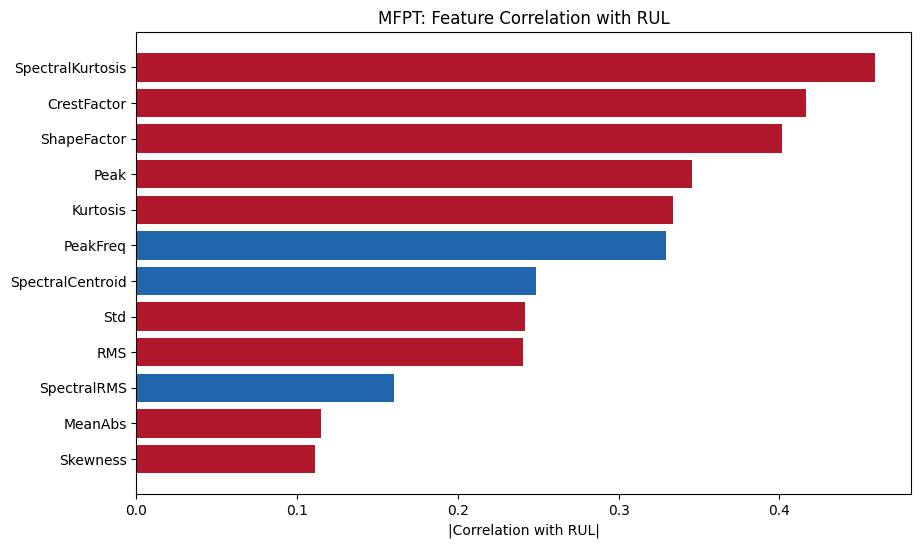


Mean |r|:  Time-domain=0.2758
           Freq-domain=0.2995


In [8]:
# Exploratory Data Analysis

# Pearson Correlation
corrs = {}
for i, name in enumerate(feature_names):
    corrs[name] = np.corrcoef(X_feat_tr_sc[:, i], y_tr)[0, 1]
corrs = pd.Series(corrs).sort_values(key=abs, ascending=False)
print("MFPT Feature correlations with RUL:")
print(corrs.to_string())

# Plot Bar chart of Feature correlations
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2166ac' if v > 0 else '#b2182b' for v in corrs.values]
ax.barh(range(len(corrs)), abs(corrs.values), color=colors)
ax.set_yticks(range(len(corrs))); ax.set_yticklabels(corrs.index)
ax.set_xlabel('|Correlation with RUL|'); ax.invert_yaxis()
ax.set_title('MFPT: Feature Correlation with RUL')
plt.savefig('/kaggle/working/figures/mfpt_feature_corr.png', bbox_inches='tight')
plt.show()

# Compare average correlation strength between time-domain and frequency-domain features
time_feats = ['RMS', 'Peak', 'Kurtosis', 'Skewness', 'CrestFactor', 'Std', 'MeanAbs', 'ShapeFactor']
freq_feats = ['SpectralCentroid', 'SpectralRMS', 'SpectralKurtosis', 'PeakFreq']
print(f"\nMean |r|:  Time-domain={np.mean([abs(corrs[f]) for f in time_feats]):.4f}")
print(f"           Freq-domain={np.mean([abs(corrs[f]) for f in freq_feats]):.4f}")

LR: RMSE=78.58, MAE=62.58, R²=-117.4923, Time=0.017s


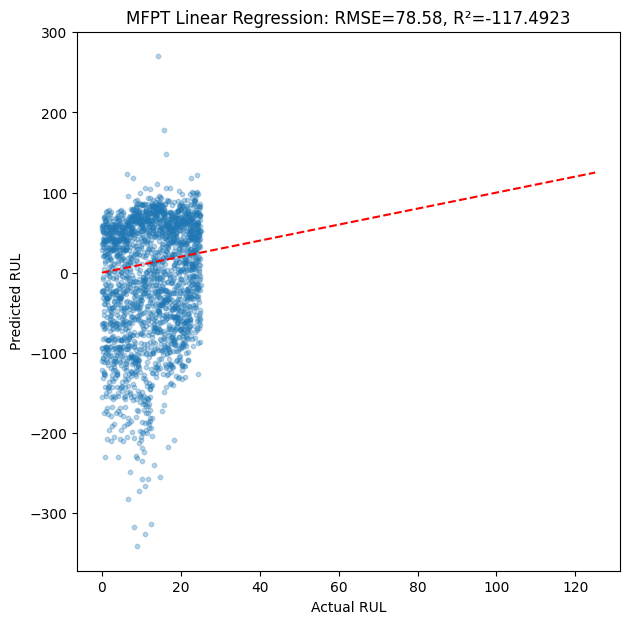

In [9]:
# Linear Regression

t0 = time.time()     # Timer for report
lr_model = LinearRegression().fit(X_feat_tr_sc, y_tr)   # Training LR on scaled features
lr_time = time.time() - t0   # Record of training time

y_pred_lr = lr_model.predict(X_feat_te_sc)   # predicting RUL for test set
lr_rmse = np.sqrt(mean_squared_error(y_te, y_pred_lr))    # RMSE
lr_mae = mean_absolute_error(y_te, y_pred_lr)      # MAE
lr_r2 = r2_score(y_te, y_pred_lr)       # R squared - proportion of variance
print(f"LR: RMSE={lr_rmse:.2f}, MAE={lr_mae:.2f}, R²={lr_r2:.4f}, Time={lr_time:.3f}s")

# Scatter plot: actual vs predicted RUL
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_te, y_pred_lr, alpha=0.3, s=10)
ax.plot([0, RUL_CAP], [0, RUL_CAP], 'r--')
ax.set_xlabel('Actual RUL'); ax.set_ylabel('Predicted RUL')
ax.set_title(f'MFPT Linear Regression: RMSE={lr_rmse:.2f}, R²={lr_r2:.4f}')
plt.savefig('/kaggle/working/figures/mfpt_lr_scatter.png')
plt.show()

Grid search:
  depth=4, lr=0.05: RMSE=32.01
  depth=4, lr=0.1: RMSE=32.71
  depth=4, lr=0.2: RMSE=30.39
  depth=6, lr=0.05: RMSE=34.55
  depth=6, lr=0.1: RMSE=35.41
  depth=6, lr=0.2: RMSE=34.19
  depth=8, lr=0.05: RMSE=36.21
  depth=8, lr=0.1: RMSE=36.94
  depth=8, lr=0.2: RMSE=37.62
Best: depth=4, lr=0.2, RMSE=30.39

XGBoost: RMSE=30.39, MAE=23.89, R²=-16.7231
vs LR: +61.3%


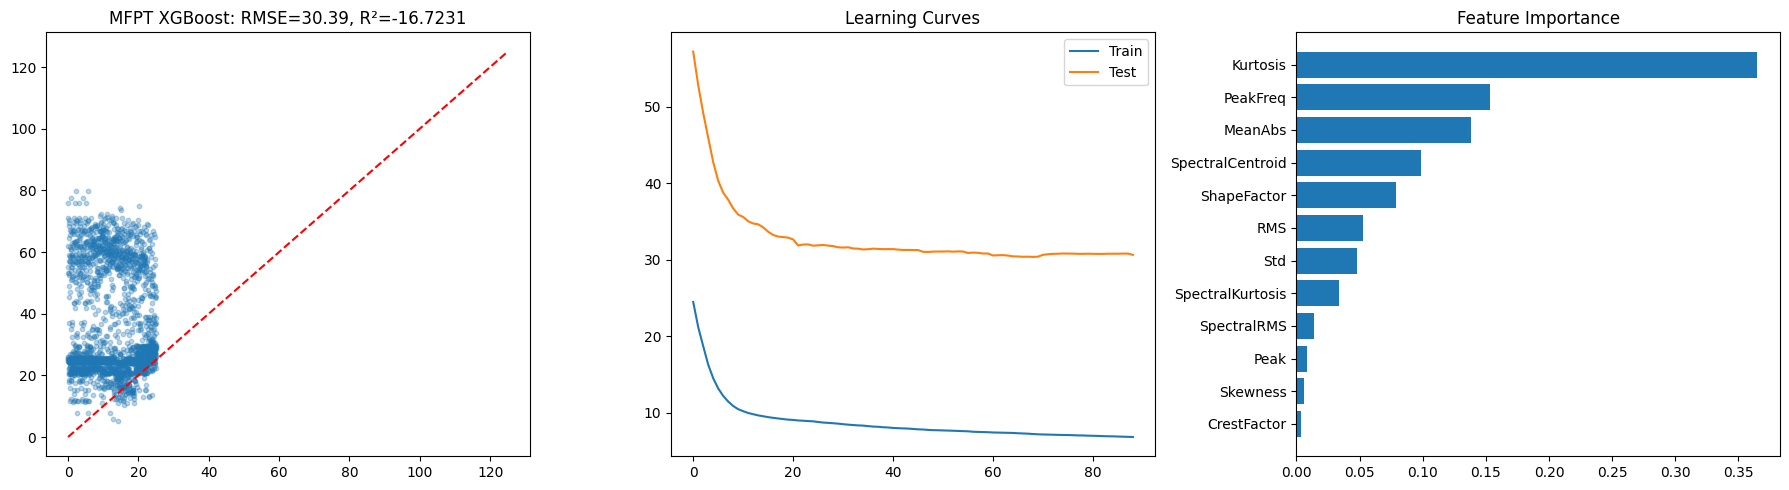

In [10]:
# XGBoost

# Testing 9 combinations of max_depth and learning_rate for XGBoost config
print("Grid search:")
grid_results = []
for md in [4, 6, 8]:                   # max_depth: how deep a decision tree can be

    for lr in [0.05, 0.1, 0.2]:         # Learning_rate: how much new trees contribute
        
        m = xgb.XGBRegressor(
            n_estimators=400,         # max 400 trees
            learning_rate=lr,
            max_depth=md,
            subsample=0.8,              # 80% of training data per tree (to prevent overfitting)
            colsample_bytree=0.8,       # 80% of features per tree
            random_state=42,
            early_stopping_rounds=20,   # stop if no improvement
            eval_metric='rmse',         # monitor RMSE
            verbosity=0)                # No progress output
        m.fit(X_feat_tr_sc, y_tr, eval_set=[(X_feat_te_sc, y_te)], verbose=0)   # Train and monitor test loss
        pred = m.predict(X_feat_te_sc)
        rmse = np.sqrt(mean_squared_error(y_te, pred))
        grid_results.append({'depth': md, 'lr': lr, 'rmse': rmse})
        print(f"  depth={md}, lr={lr}: RMSE={rmse:.2f}")

gdf = pd.DataFrame(grid_results)
best = gdf.loc[gdf['rmse'].idxmin()]    # finding lowest RMSE
print(f"Best: depth={int(best['depth'])}, lr={best['lr']}, RMSE={best['rmse']:.2f}")

t0 = time.time()

# training final model with best hyperparameters 
xgb_model = xgb.XGBRegressor(n_estimators=400, learning_rate=best['lr'],
    max_depth=int(best['depth']), subsample=0.8, colsample_bytree=0.8,
    random_state=42, early_stopping_rounds=20, eval_metric='rmse', verbosity=0)

xgb_model.fit(X_feat_tr_sc, y_tr,
              eval_set=[(X_feat_tr_sc, y_tr), (X_feat_te_sc, y_te)], verbose=0)  #train and test 
xgb_time = time.time() - t0

y_pred_xgb = xgb_model.predict(X_feat_te_sc)
xgb_rmse = np.sqrt(mean_squared_error(y_te, y_pred_xgb))
xgb_mae = mean_absolute_error(y_te, y_pred_xgb)
xgb_r2 = r2_score(y_te, y_pred_xgb)
print(f"\nXGBoost: RMSE={xgb_rmse:.2f}, MAE={xgb_mae:.2f}, R²={xgb_r2:.4f}")
print(f"vs LR: {(1-xgb_rmse/lr_rmse)*100:+.1f}%")

# Plotting data
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(y_te, y_pred_xgb, alpha=0.3, s=10)
axes[0].plot([0,RUL_CAP],[0,RUL_CAP],'r--')
axes[0].set_title(f'MFPT XGBoost: RMSE={xgb_rmse:.2f}, R²={xgb_r2:.4f}')
ev = xgb_model.evals_result()
axes[1].plot(ev['validation_0']['rmse'], label='Train')
axes[1].plot(ev['validation_1']['rmse'], label='Test')
axes[1].legend(); axes[1].set_title('Learning Curves')
imp = xgb_model.feature_importances_
idx = np.argsort(imp)
axes[2].barh(range(len(idx)), imp[idx])
axes[2].set_yticks(range(len(idx))); axes[2].set_yticklabels([feature_names[i] for i in idx])
axes[2].set_title('Feature Importance')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/mfpt_xgboost_results.png')
plt.show()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1024, 64)       │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 256, 128)       │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 64, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,881 (417.50 KB)

 Trainable params: 106,369 (415.50 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 29s 182ms/step - loss: 4358.5327 - mae: 57.1303 - val_loss: 82.4484 - val_mae: 7.5015 - learning_rate: 0.0010
Epoch 2/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 168ms/step - loss: 367.6278 - mae: 15.1112 - val_loss: 265.4869 - val_mae: 14.5807 - learning_rate: 0.0010
Epoch 3/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 178ms/step - loss: 240.2032 - mae: 12.0392 - val_loss: 580.0385 - val_mae: 20.9525 - learning_rate: 0.0010
Epoch 4/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 177ms/step - loss: 216.7188 - mae: 11.4033 - val_loss: 966.6583 - val_mae: 27.2640 - learning_rate: 0.0010
Epoch 5/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 176ms/step - loss: 205.7656 - mae: 11.1022 - val_loss: 846.9292 - val_mae: 25.0297 - learning_rate: 0.0010
Epoch 6/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 175ms/step - loss: 196.4418 - mae: 10.7713 - val_loss: 1237.2731 - val_mae: 29.4120 - learning_rate: 0.0010
Epoch 7/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 175ms/step - loss: 181.6603 - mae: 10.4020 - val_l

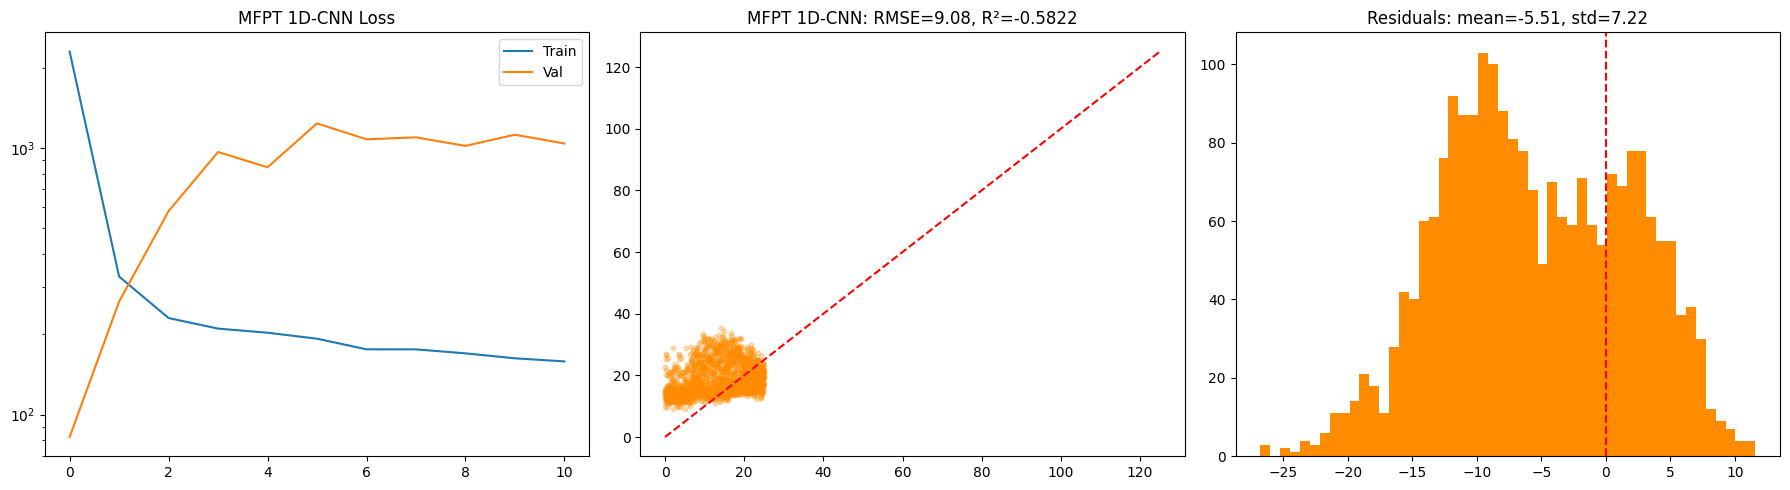

In [11]:
## 1D CNN

cnn = keras.Sequential([
    layers.Input(shape=(WINDOW_SIZE, 1)), # Input
    
    # BLOCK 1
    layers.Conv1D(64, 16, activation='relu', padding='same'), #64 filters, 16 samples wide
    layers.BatchNormalization(),  #Normalise
    layers.MaxPooling1D(4),   # 1024 to 256
    layers.Dropout(0.2),  #Randomly switches off 20% of neurons each training step

    # BLOCK 2
    layers.Conv1D(128, 8, activation='relu', padding='same'),  # 128 filters, 8 samples wide
    layers.BatchNormalization(),  
    layers.MaxPooling1D(4),          # 256 to 64
    layers.Dropout(0.2),

    # BLOCK 3
    layers.Conv1D(64, 4, activation='relu', padding='same'),  #64 filters, 4 samples wide
    layers.BatchNormalization(),           
    layers.GlobalAveragePooling1D(),          # Averaging across all 64 remaining timesteps
    layers.Dropout(0.3),                 # raising dropout before dense layer

    # REGRESSION HEAD
    layers.Dense(64, activation='relu'),     # 64 neurons
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),      # 32 neurons
    layers.Dense(1, activation='linear')       # Output predicted RUL
])

cnn.compile
    (optimizer=optimizers.Adam(1e-3),   # Adam optimizer
    loss='mse',                 # Mean squared error loss
    metrics=['mae'])            # MAE
cnn.summary()

t0 = time.time()
h_cnn = cnn.fit(
    X_seq_tr_n, y_tr,           # training data
    validation_data=(X_seq_te_n, y_te),      # test data
    epochs=60,       # Maximum 60 training stages through data
    batch_size=64,    # Process 64 windows before updating weights
    callbacks=[
        callbacks.EarlyStopping('val_loss', patience=10, restore_best_weights=True),
        # Stop training if validatio loss hasnt improved for 10 consequtive epochs, restore best weights
        callbacks.ReduceLROnPlateau('val_loss', factor=0.5, patience=5)],
        # Halve the learning rate if validation loss hasnt improved for 5 epochs
    
    verbose=1)      
cnn_time = time.time() - t0

y_pred_cnn = cnn.predict(X_seq_te_n, batch_size=64).ravel()  # Predict on test set
cnn_rmse = np.sqrt(mean_squared_error(y_te, y_pred_cnn))
cnn_mae = mean_absolute_error(y_te, y_pred_cnn)
cnn_r2 = r2_score(y_te, y_pred_cnn)

print(f"\n1D-CNN: RMSE={cnn_rmse:.2f}, MAE={cnn_mae:.2f}, R²={cnn_r2:.4f}")
print(f"Params={cnn.count_params():,}, Time={cnn_time:.0f}s, Epochs={len(h_cnn.history['loss'])}")
print(f"vs XGBoost: {(1-cnn_rmse/xgb_rmse)*100:+.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(h_cnn.history['loss'], label='Train'); axes[0].plot(h_cnn.history['val_loss'], label='Val')
axes[0].legend(); axes[0].set_yscale('log'); axes[0].set_title('MFPT 1D-CNN Loss')
axes[1].scatter(y_te, y_pred_cnn, alpha=0.3, s=10, c='darkorange')
axes[1].plot([0,RUL_CAP],[0,RUL_CAP],'r--')
axes[1].set_title(f'MFPT 1D-CNN: RMSE={cnn_rmse:.2f}, R²={cnn_r2:.4f}')
r = y_te - y_pred_cnn
axes[2].hist(r, bins=50, color='darkorange'); axes[2].axvline(0, color='red', ls='--')
axes[2].set_title(f'Residuals: mean={r.mean():.2f}, std={r.std():.2f}')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/mfpt_cnn_results.png')
plt.show()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 1024, 64)       │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1024, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 256, 128)       │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,433 (509.50 KB)

 Trainable params: 130,049 (508.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 39s 241ms/step - loss: 5273.9072 - mae: 65.8658 - val_loss: 232.9222 - val_mae: 12.9933 - learning_rate: 0.0010
Epoch 2/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 237ms/step - loss: 1368.9825 - mae: 29.9702 - val_loss: 1157.1501 - val_mae: 32.2180 - learning_rate: 0.0010
Epoch 3/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 238ms/step - loss: 385.5256 - mae: 15.1894 - val_loss: 1242.6598 - val_mae: 27.6469 - learning_rate: 0.0010
Epoch 4/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 34s 240ms/step - loss: 231.7113 - mae: 11.8083 - val_loss: 1221.5543 - val_mae: 27.8193 - learning_rate: 0.0010
Epoch 5/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 236ms/step - loss: 214.5645 - mae: 11.2186 - val_loss: 1275.1630 - val_mae: 28.5588 - learning_rate: 0.0010
Epoch 6/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 236ms/step - loss: 217.9870 - mae: 11.3504 - val_loss: 953.2878 - val_mae: 23.3520 - learning_rate: 0.0010
Epoch 7/60
140/140 ━━━━━━━━━━━━━━━━━━━━ 34s 240ms/step - loss: 212.7200 - mae: 11.1055 -

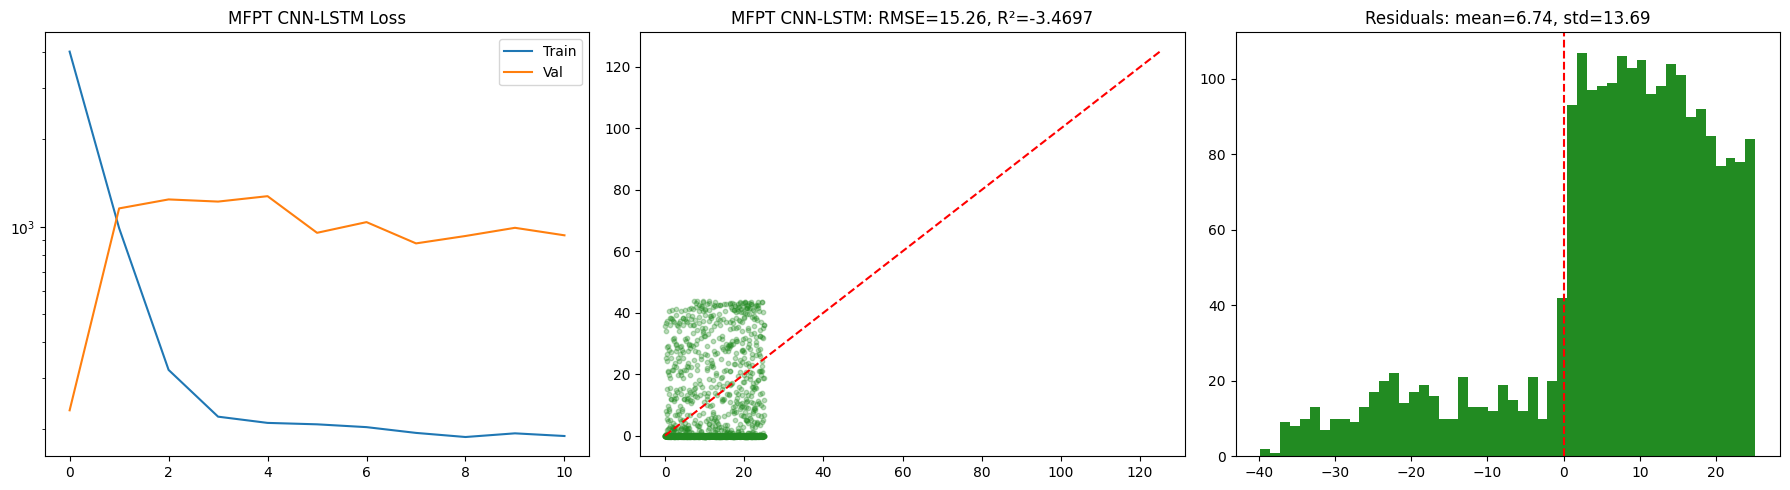

In [12]:
##CNN-LSTM

cl = keras.Sequential([
    layers.Input(shape=(WINDOW_SIZE, 1)),

    # BLOCK 1 - identical to CNN
    layers.Conv1D(64, 16, activation='relu', padding='same'),
    layers.BatchNormalization(), 
    layers.MaxPooling1D(4), 
    layers.Dropout(0.2),

    # BLOCK 2 - identical to CNN
    layers.Conv1D(128, 8, activation='relu', padding='same'),
    layers.BatchNormalization(), 
    layers.MaxPooling1D(4), 
    layers.Dropout(0.2),

    # LSTM LAYERS
    layers.LSTM(64, return_sequences=True),  # 64 unit LSTM
    layers.Dropout(0.2),      #  Necessary for 2nd LSTM to recieve full sequence as input
    layers.LSTM(32, return_sequences=False),   #32 -unit LSTM
    layers.Dropout(0.2),
    
    layers.Dense(32, activation='relu'), 
    layers.Dropout(0.2),
    layers.Dense(1, activation='linear')
])
cl.compile(optimizer=optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
cl.summary()

t0 = time.time()
# Training and validating
h_cl = cl.fit(X_seq_tr_n, y_tr, 
              validation_data=(X_seq_te_n, y_te),
              epochs=60,   # maximum 60 training processes
              batch_size=64,    # 64 windows at a time
              callbacks=[
                  callbacks.EarlyStopping('val_loss', patience=10, restore_best_weights=True),
                  # stop training if val loss not improved over 10 epochs       
                  callbacks.ReduceLROnPlateau('val_loss', factor=0.5, patience=5)],
                  # halve learning rate if validation doesnt improve over 5 epochs
              verbose=1)
cl_time = time.time() - t0

y_pred_cl = cl.predict(X_seq_te_n, batch_size=64).ravel()   # predicting on test set
cl_rmse = np.sqrt(mean_squared_error(y_te, y_pred_cl))
cl_mae = mean_absolute_error(y_te, y_pred_cl)
cl_r2 = r2_score(y_te, y_pred_cl)

print(f"\nCNN-LSTM: RMSE={cl_rmse:.2f}, MAE={cl_mae:.2f}, R²={cl_r2:.4f}")
print(f"Params={cl.count_params():,}, Time={cl_time:.0f}s, Epochs={len(h_cl.history['loss'])}")
print(f"vs XGBoost: {(1-cl_rmse/xgb_rmse)*100:+.1f}%")
print(f"vs CNN:     {(1-cl_rmse/cnn_rmse)*100:+.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(h_cl.history['loss'], label='Train'); axes[0].plot(h_cl.history['val_loss'], label='Val')
axes[0].legend(); axes[0].set_yscale('log'); axes[0].set_title('MFPT CNN-LSTM Loss')
axes[1].scatter(y_te, y_pred_cl, alpha=0.3, s=10, c='forestgreen')
axes[1].plot([0,RUL_CAP],[0,RUL_CAP],'r--')
axes[1].set_title(f'MFPT CNN-LSTM: RMSE={cl_rmse:.2f}, R²={cl_r2:.4f}')
r2 = y_te - y_pred_cl
axes[2].hist(r2, bins=50, color='forestgreen'); axes[2].axvline(0, color='red', ls='--')
axes[2].set_title(f'Residuals: mean={r2.mean():.2f}, std={r2.std():.2f}')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/mfpt_cnn_lstm_results.png')
plt.show()


=== MFPT MODEL COMPARISON ===
Model                    RMSE      MAE       R²       Time
----------------------------------------------------------
Linear Regression       78.58    62.58 -117.4923       0.0s
XGBoost                 30.39    23.89 -16.7231       0.1s
1D-CNN                   9.08     7.50  -0.5822     274.2s
CNN-LSTM                15.26    12.99  -3.4697     372.1s


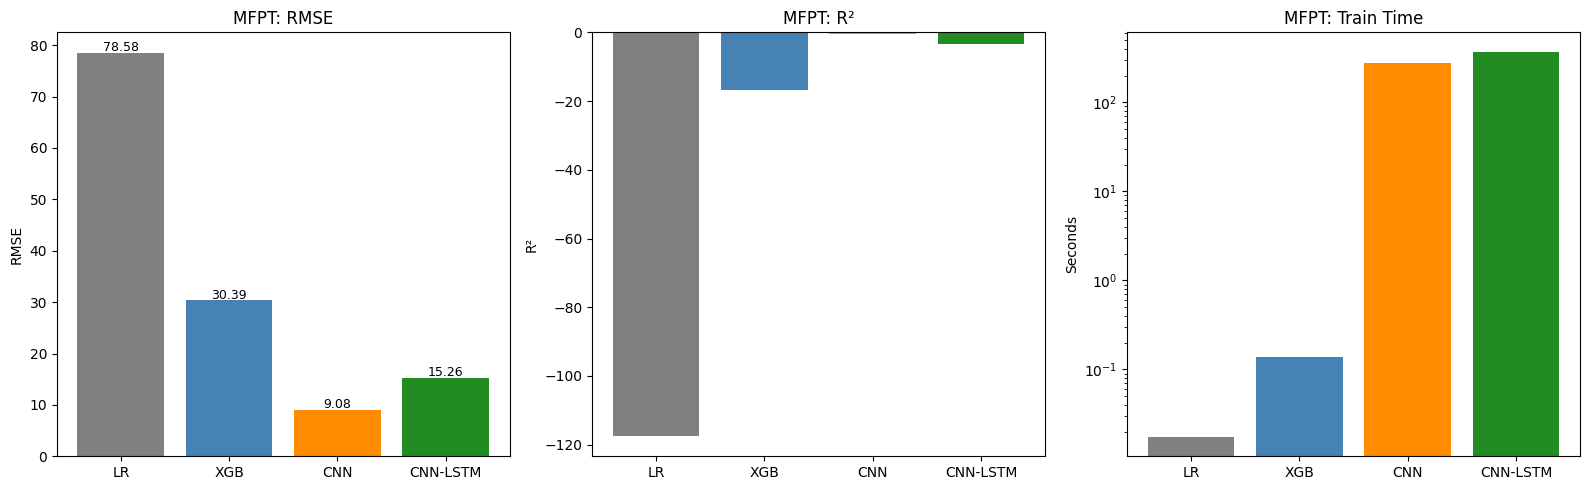

In [13]:
# Model comparison summary

print("\n MFPT MODEL COMPARISON")
print(f"{'Model':<20} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'Time':>10}")
print("-" * 58)
for name, rmse, mae, r2, t in [
    ('Linear Regression', lr_rmse, lr_mae, lr_r2, lr_time),
    ('XGBoost', xgb_rmse, xgb_mae, xgb_r2, xgb_time),
    ('1D-CNN', cnn_rmse, cnn_mae, cnn_r2, cnn_time),
    ('CNN-LSTM', cl_rmse, cl_mae, cl_r2, cl_time)]:
    print(f"{name:<20} {rmse:>8.2f} {mae:>8.2f} {r2:>8.4f} {t:>9.1f}s")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
names = ['LR', 'XGB', 'CNN', 'CNN-LSTM']
c = ['grey', 'steelblue', 'darkorange', 'forestgreen']
rmses = [lr_rmse, xgb_rmse, cnn_rmse, cl_rmse]
axes[0].bar(names, rmses, color=c); axes[0].set_ylabel('RMSE'); axes[0].set_title('MFPT: RMSE')
for i,v in enumerate(rmses): axes[0].text(i, v+0.3, f'{v:.2f}', ha='center', fontsize=9)
axes[1].bar(names, [lr_r2, xgb_r2, cnn_r2, cl_r2], color=c); axes[1].set_ylabel('R²'); axes[1].set_title('MFPT: R²')
axes[2].bar(names, [lr_time, xgb_time, cnn_time, cl_time], color=c)
axes[2].set_ylabel('Seconds'); axes[2].set_title('MFPT: Train Time'); axes[2].set_yscale('log')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/mfpt_comparison.png')
plt.show()

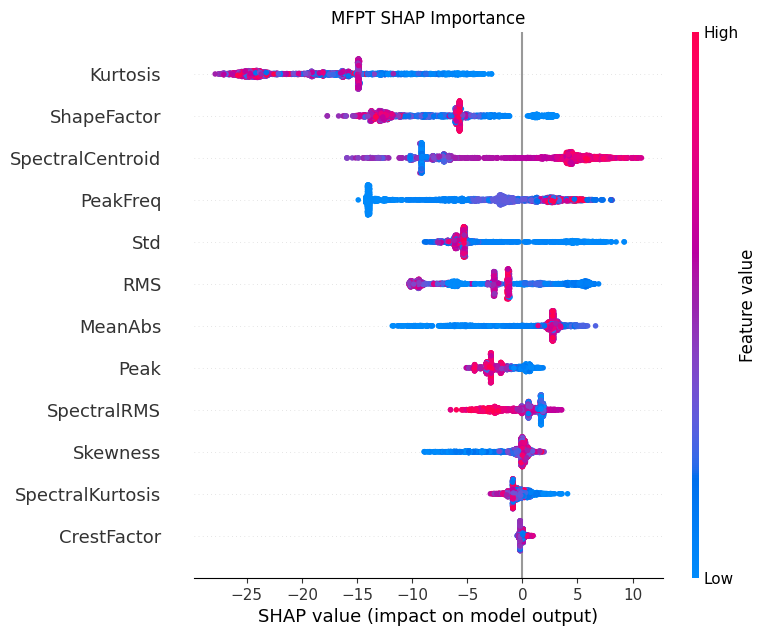

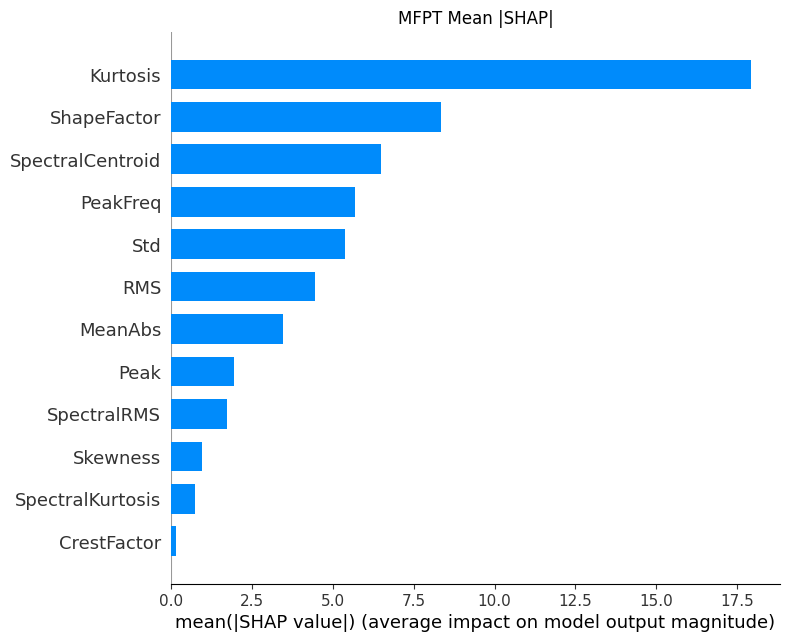

MFPT SHAP importance:
              Kurtosis: 17.9234 (31.3%)
           ShapeFactor: 8.3400 (14.6%)
      SpectralCentroid: 6.4943 (11.3%)
              PeakFreq: 5.6879 (9.9%)
                   Std: 5.3868 (9.4%)
                   RMS: 4.4490 (7.8%)
               MeanAbs: 3.4509 (6.0%)
                  Peak: 1.9591 (3.4%)
           SpectralRMS: 1.7413 (3.0%)
              Skewness: 0.9625 (1.7%)
      SpectralKurtosis: 0.7305 (1.3%)
           CrestFactor: 0.1597 (0.3%)


In [14]:
# SHAP analysis

import shap
explainer = shap.TreeExplainer(xgb_model)  # SHAP for tree-based models
sv = explainer.shap_values(X_feat_te_sc)    # calculate shap values for every test sample

# Beeswarm plot: every dot is one test samples (red=high, blue=low)
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_feat_te_sc, feature_names=feature_names, show=False)
plt.title('MFPT SHAP Importance')
plt.savefig('/kaggle/working/figures/mfpt_shap_summary.png', bbox_inches='tight')
plt.show()

# Bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_feat_te_sc, feature_names=feature_names, plot_type='bar', show=False)
plt.title('MFPT Mean |SHAP|')
plt.savefig('/kaggle/working/figures/mfpt_shap_bar.png', bbox_inches='tight')
plt.show()

# print percentages for report
ms = np.abs(sv).mean(0); total = ms.sum()
print("MFPT SHAP importance:")
for i in np.argsort(ms)[::-1]:
    print(f"  {feature_names[i]:>20s}: {ms[i]:.4f} ({ms[i]/total*100:.1f}%)")

In [15]:
# Cross dataset comparison 

print("\n" + "=" * 60)
print("  N-CMAPSS vs MFPT COMPARISON")
print("=" * 60)

# Hardcoded N-CMAPSS results
nc = {'LR': 11.81, 'XGB': 9.26, 'CNN': 5.85, 'CNNLSTM': 5.81}
mf = {'LR': lr_rmse, 'XGB': xgb_rmse, 'CNN': cnn_rmse, 'CNNLSTM': cl_rmse}

print(f"\n{'Model':<20} {'N-CMAPSS':>10} {'MFPT':>10}")
print("-" * 42)
for key in ['LR', 'XGB', 'CNN', 'CNNLSTM']:
    print(f"{key:<20} {nc[key]:>10.2f} {mf[key]:>10.2f}")

nc_order = sorted(nc, key=lambda x: nc[x])
mf_order = sorted(mf, key=lambda x: mf[x])
print(f"\nN-CMAPSS ranking: {' < '.join(nc_order)}")
print(f"MFPT ranking:     {' < '.join(mf_order)}")
print(f"Rankings match: {nc_order == mf_order}")


  N-CMAPSS vs MFPT COMPARISON

Model                  N-CMAPSS       MFPT
------------------------------------------
LR                        11.81      78.58
XGB                        9.26      30.39
CNN                        5.85       9.08
CNNLSTM                    5.81      15.26

N-CMAPSS ranking: CNNLSTM < CNN < XGB < LR
MFPT ranking:     CNN < CNNLSTM < XGB < LR
Rankings match: False


In [16]:
# Report Numbers

cnn.save('/kaggle/working/mfpt_cnn.keras')
cl.save('/kaggle/working/mfpt_cnn_lstm.keras')
xgb_model.save_model('/kaggle/working/mfpt_xgb.json')

print("\n MFPT RESULTS FOR REPORT \n")
print(f"Dataset: MFPT Bearing, {N_WINDOWS} windows from {len(recordings)} recordings")
print(f"Window: {WINDOW_SIZE} samples, step={STEP}, RUL cap={RUL_CAP}")
print(f"Features: {n_tab_features} hand-engineered (8 time-domain + 4 frequency-domain)")
print(f"Split: {split} train / {N_WINDOWS-split} test (temporal)")
print(f"\nLinear Regression: RMSE={lr_rmse:.2f}, MAE={lr_mae:.2f}, R²={lr_r2:.4f}")
print(f"XGBoost:           RMSE={xgb_rmse:.2f}, MAE={xgb_mae:.2f}, R²={xgb_r2:.4f}")
print(f"1D-CNN:            RMSE={cnn_rmse:.2f}, MAE={cnn_mae:.2f}, R²={cnn_r2:.4f}, params={cnn.count_params():,}")
print(f"CNN-LSTM:          RMSE={cl_rmse:.2f}, MAE={cl_mae:.2f}, R²={cl_r2:.4f}, params={cl.count_params():,}")
print(f"\nXGBoost vs LR:      {(1-xgb_rmse/lr_rmse)*100:+.1f}%")
print(f"1D-CNN vs XGBoost:  {(1-cnn_rmse/xgb_rmse)*100:+.1f}%")
print(f"CNN-LSTM vs XGBoost:{(1-cl_rmse/xgb_rmse)*100:+.1f}%")
print(f"\nFigures:")
for f in sorted(os.listdir('/kaggle/working/figures/')): print(f"  {f}")



=== MFPT RESULTS FOR REPORT ===

Dataset: MFPT Bearing, 11133 windows from 21 recordings
Window: 1024 samples, step=512, RUL cap=125
Features: 12 hand-engineered (8 time-domain + 4 frequency-domain)
Split: 8906 train / 2227 test (temporal)

Linear Regression: RMSE=78.58, MAE=62.58, R²=-117.4923
XGBoost:           RMSE=30.39, MAE=23.89, R²=-16.7231
1D-CNN:            RMSE=9.08, MAE=7.50, R²=-0.5822, params=106,881
CNN-LSTM:          RMSE=15.26, MAE=12.99, R²=-3.4697, params=130,433

XGBoost vs LR:      +61.3%
1D-CNN vs XGBoost:  +70.1%
CNN-LSTM vs XGBoost:+49.8%

Figures:
  mfpt_cnn_lstm_results.png
  mfpt_cnn_results.png
  mfpt_comparison.png
  mfpt_feature_corr.png
  mfpt_lr_scatter.png
  mfpt_rul_distribution.png
  mfpt_shap_bar.png
  mfpt_shap_summary.png
  mfpt_xgboost_results.png

Done.
